In [8]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [9]:
username = "Abhiix0"

url = f"https://api.github.com/users/{username}/repos"

response = requests.get(url)

repos = response.json()

print(f"Total repositories fetched: {len(repos)}")

Total repositories fetched: 25


In [10]:
df = pd.DataFrame(repos)

df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,is_template,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch
0,1060685394,R_kgDOPzjGUg,30-Days-Of-React,Abhiix0/30-Days-Of-React,False,"{'login': 'Abhiix0', 'id': 200814392, 'node_id...",https://github.com/Abhiix0/30-Days-Of-React,30 Days of React challenge is a step by step ...,True,https://api.github.com/repos/Abhiix0/30-Days-O...,...,False,False,True,all,[],public,0,0,0,master
1,1029715409,R_kgDOPWA10Q,Abhiix0,Abhiix0/Abhiix0,False,"{'login': 'Abhiix0', 'id': 200814392, 'node_id...",https://github.com/Abhiix0/Abhiix0,NaN,False,https://api.github.com/repos/Abhiix0/Abhiix0,...,False,False,True,all,[],public,0,0,0,main
2,1174478679,R_kgDORgEfVw,AI-Data-Analyst,Abhiix0/AI-Data-Analyst,False,"{'login': 'Abhiix0', 'id': 200814392, 'node_id...",https://github.com/Abhiix0/AI-Data-Analyst,Multi-agent AI pipeline that profiles any data...,False,https://api.github.com/repos/Abhiix0/AI-Data-A...,...,False,False,True,all,[],public,1,0,0,main
3,1030277410,R_kgDOPWjJIg,Anime-EDA,Abhiix0/Anime-EDA,False,"{'login': 'Abhiix0', 'id': 200814392, 'node_id...",https://github.com/Abhiix0/Anime-EDA,NaN,False,https://api.github.com/repos/Abhiix0/Anime-EDA,...,False,False,True,all,[],public,0,0,0,main
4,1037216443,R_kgDOPdKquw,cie-harmony-hub,Abhiix0/cie-harmony-hub,False,"{'login': 'Abhiix0', 'id': 200814392, 'node_id...",https://github.com/Abhiix0/cie-harmony-hub,NaN,True,https://api.github.com/repos/Abhiix0/cie-harmo...,...,False,False,True,all,[],public,2,0,0,main


In [6]:
df = df[[
    "name",
    "language",
    "stargazers_count",
    "forks_count",
    "watchers_count",
    "open_issues_count",
    "created_at"
]]

df.head()

,name,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at
0,30-Days-Of-React,JavaScript,0,0,0,0,2025-09-20T11:37:59Z
1,Abhiix0,NaN,0,0,0,0,2025-07-31T13:10:38Z
2,AI-Data-Analyst,Python,0,1,0,0,2026-03-06T13:44:26Z
3,Anime-EDA,Python,0,0,0,0,2025-08-01T11:20:43Z
4,cie-harmony-hub,TypeScript,0,2,0,0,2025-08-13T08:36:12Z


In [7]:
df["created_at"] = pd.to_datetime(df["created_at"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   name               25 non-null     str                
 1   language           19 non-null     str                
 2   stargazers_count   25 non-null     int64              
 3   forks_count        25 non-null     int64              
 4   watchers_count     25 non-null     int64              
 5   open_issues_count  25 non-null     int64              
 6   created_at         25 non-null     datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), int64(4), str(2)
memory usage: 1.5 KB


In [8]:
language_counts = df["language"].value_counts()

print(language_counts)

language
TypeScript          9
Python              5
Jupyter Notebook    2
Java                2
JavaScript          1
Name: count, dtype: int64


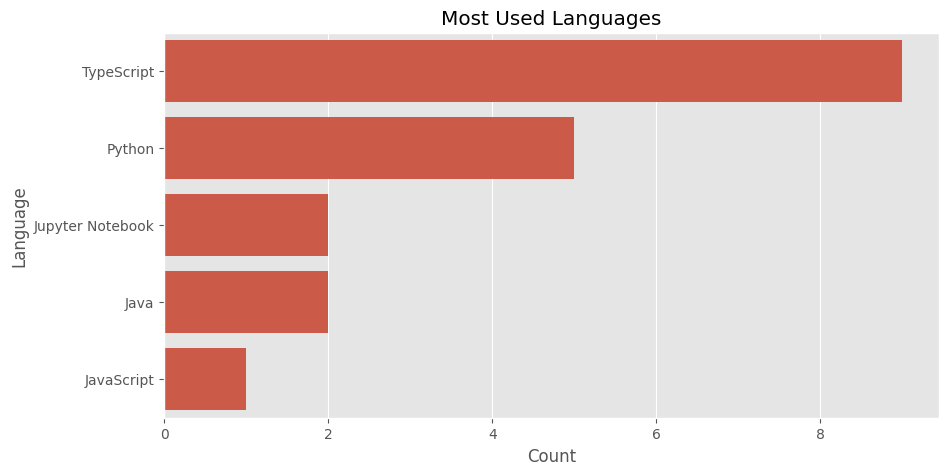

In [11]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="language",
    order=df["language"].value_counts().index
)

plt.title("Most Used Languages")
plt.xlabel("Count")
plt.ylabel("Language")

plt.show()

In [14]:
df["year"] = df["created_at"].dt.year

repo_growth = df["year"].value_counts().sort_index()

repo_growth

year
2025    14
2026    11
Name: count, dtype: int64

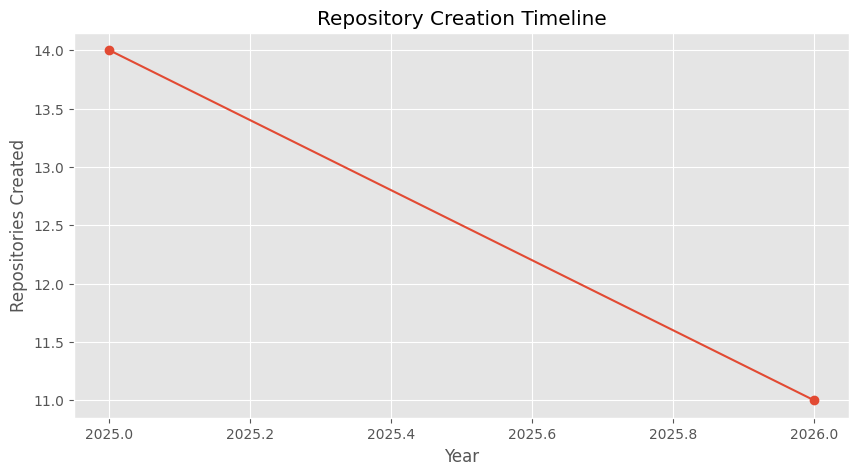

In [15]:
plt.figure(figsize=(10, 5))

repo_growth.plot(kind="line", marker="o")

plt.title("Repository Creation Timeline")
plt.xlabel("Year")
plt.ylabel("Repositories Created")

plt.show()

In [17]:
df["engagement_score"] = (
    df["stargazers_count"] +
    df["forks_count"] +
    df["watchers_count"]
)

df[[
    "name",
    "engagement_score"
]].sort_values(
    by="engagement_score",
    ascending=False
).head()

,name,engagement_score
12,monastery360,4
21,Talk2book,3
19,Python-Projects,2
4,cie-harmony-hub,2
2,AI-Data-Analyst,1


In [29]:
owner = "Abhiix0"
repo = "Abhiix0"

In [30]:
commit_url = f"https://api.github.com/repos/{owner}/{repo}/commits"

commit_response = requests.get(commit_url)

commit_data = commit_response.json()

print(f"Total commits fetched: {len(commit_data)}")

Total commits fetched: 30


In [31]:
commit_data[0]

{'sha': '510eee01d774b5c715626374d18428e1622b23ff',
 'node_id': 'C_kwDOPWA10doAKDUxMGVlZTAxZDc3NGI1YzcxNTYyNjM3NGQxODQyOGUxNjIyYjIzZmY',
 'commit': {'author': {'name': 'Abhiix0',
   'email': '24r21a6778@mlrit.ac.in',
   'date': '2026-04-22T12:19:19Z'},
  'committer': {'name': 'GitHub',
   'email': 'noreply@github.com',
   'date': '2026-04-22T12:19:19Z'},
  'message': "Update text in banner.svg from 'Name’s Abhinav' to 'ASG'",
  'tree': {'sha': '28d74897cfa498e3e0b79af4c83eaa3098311e66',
   'url': 'https://api.github.com/repos/Abhiix0/Abhiix0/git/trees/28d74897cfa498e3e0b79af4c83eaa3098311e66'},
  'url': 'https://api.github.com/repos/Abhiix0/Abhiix0/git/commits/510eee01d774b5c715626374d18428e1622b23ff',
  'comment_count': 0,
  'verification': {'verified': True,
   'reason': 'valid',
   'signature': '-----BEGIN PGP SIGNATURE-----\n\nwsFcBAABCAAQBQJp6LzHCRC1aQ7uu5UhlAAAErUQAFH3BeuvApiQOjBlrw1O1SB+\nIerlydkVQS3GvGVZxMbADpEkiKIfvnO9b2CaURJuezCsiJrQVMHc/8Ajqw27z2xt\nkqwYqftnQgN8m3F5d96d/iHU5

In [32]:
commit_list = []

for commit in commit_data:
    commit_info = {
        "message": commit["commit"]["message"],
        "author": commit["commit"]["author"]["name"],
        "date": commit["commit"]["author"]["date"]
    }

    commit_list.append(commit_info)

commit_df = pd.DataFrame(commit_list)

commit_df.head()

,message,author,date
0,Update text in banner.svg from 'Name’s Abhinav...,Abhiix0,2026-04-22T12:19:19Z
1,Update README with new project descriptions an...,Abhiix0,2026-04-22T12:17:40Z
2,Delete assets/arsenal.svg,Abhiix0,2026-04-22T12:08:22Z
3,Add arsenal.svg with programming stack design\...,Abhiix0,2026-04-22T11:58:16Z
4,Resize SVG banner height and adjust elements,Abhiix0,2026-04-22T11:47:44Z


In [33]:
commit_df["date"] = pd.to_datetime(commit_df["date"])

commit_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype              
---  ------   --------------  -----              
 0   message  30 non-null     str                
 1   author   30 non-null     str                
 2   date     30 non-null     datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), str(2)
memory usage: 852.0 bytes


In [34]:
commit_df["day"] = commit_df["date"].dt.date

daily_commits = commit_df["day"].value_counts().sort_index()

daily_commits

day
2025-09-07     2
2025-09-21     1
2025-10-31     1
2026-01-06     1
2026-01-27     1
2026-02-01     1
2026-02-06     1
2026-03-18     2
2026-03-26     2
2026-04-18     1
2026-04-22    17
Name: count, dtype: int64

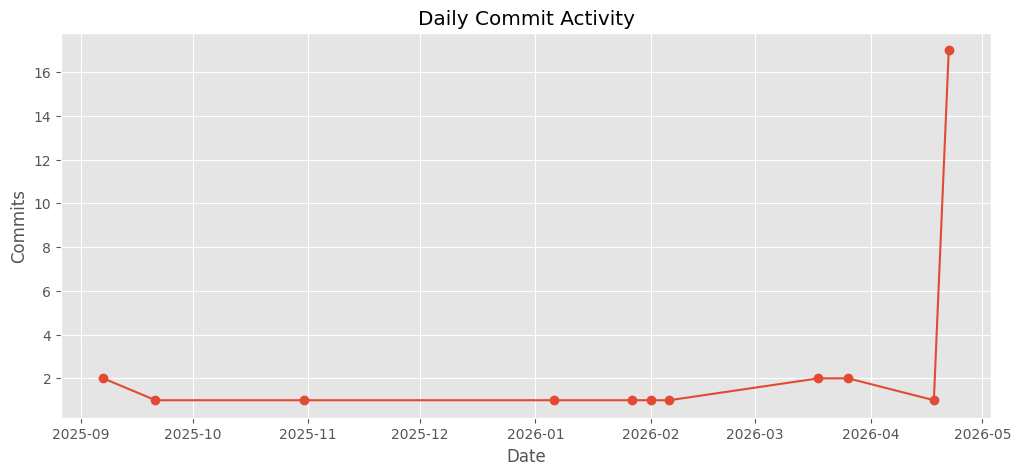

In [35]:
plt.figure(figsize=(12, 5))

daily_commits.plot(kind="line", marker="o")

plt.title("Daily Commit Activity")
plt.xlabel("Date")
plt.ylabel("Commits")

plt.show()

In [36]:
commit_df["hour"] = commit_df["date"].dt.hour

commit_df["hour"].head()

0    12
1    12
2    12
3    11
4    11
Name: hour, dtype: int32

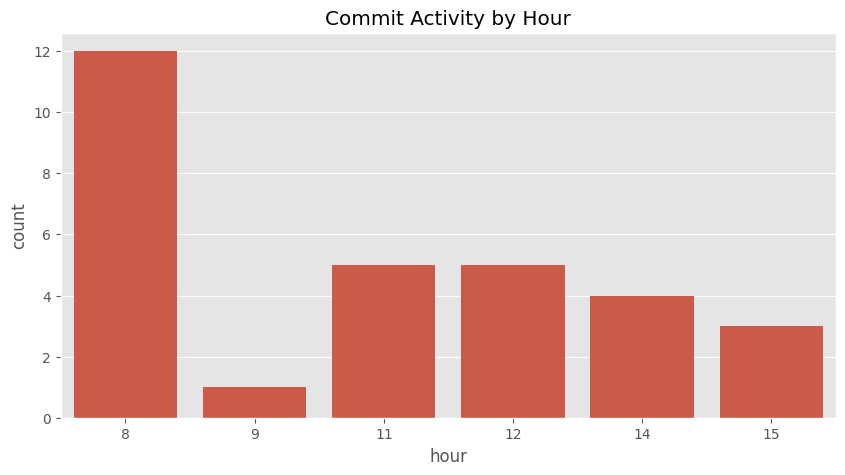

In [38]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=commit_df,
    x="hour"
)

plt.title("Commit Activity by Hour")

plt.show()

In [3]:
owner = "Abhiix0"
repo = "github-insights-engine"

contributors_url = f"https://api.github.com/repos/{owner}/{repo}/contributors"

response = requests.get(contributors_url)

contributors = response.json()

contributors[:2]

[{'login': 'Abhiix0',
  'id': 200814392,
  'node_id': 'U_kgDOC_gvOA',
  'avatar_url': 'https://avatars.githubusercontent.com/u/200814392?v=4',
  'gravatar_id': '',
  'url': 'https://api.github.com/users/Abhiix0',
  'html_url': 'https://github.com/Abhiix0',
  'followers_url': 'https://api.github.com/users/Abhiix0/followers',
  'following_url': 'https://api.github.com/users/Abhiix0/following{/other_user}',
  'gists_url': 'https://api.github.com/users/Abhiix0/gists{/gist_id}',
  'starred_url': 'https://api.github.com/users/Abhiix0/starred{/owner}{/repo}',
  'subscriptions_url': 'https://api.github.com/users/Abhiix0/subscriptions',
  'organizations_url': 'https://api.github.com/users/Abhiix0/orgs',
  'repos_url': 'https://api.github.com/users/Abhiix0/repos',
  'events_url': 'https://api.github.com/users/Abhiix0/events{/privacy}',
  'received_events_url': 'https://api.github.com/users/Abhiix0/received_events',
  'type': 'User',
  'user_view_type': 'public',
  'site_admin': False,
  'contrib

In [4]:
contributor_list = []

for contributor in contributors:
    contributor_info = {
        "username": contributor["login"],
        "contributions": contributor["contributions"]
    }

    contributor_list.append(contributor_info)

contributors_df = pd.DataFrame(contributor_list)

contributors_df

,username,contributions
0,Abhiix0,5


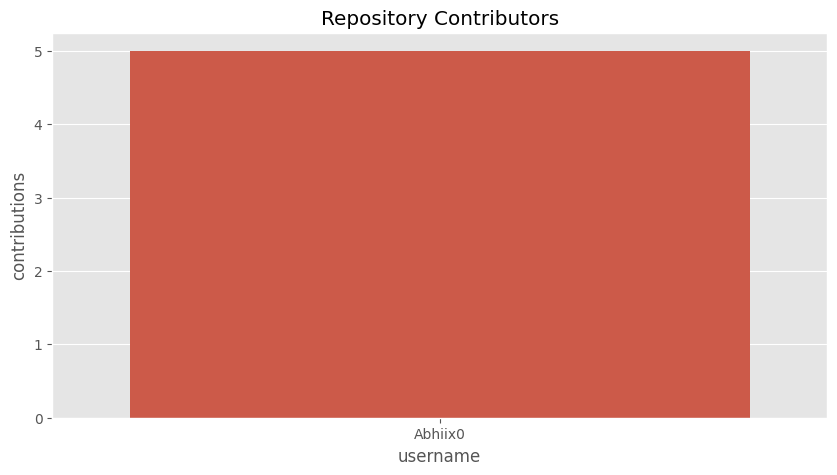

In [5]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=contributors_df,
    x="username",
    y="contributions"
)

plt.title("Repository Contributors")

plt.show()

In [11]:
df["health_score"] = (
    df["stargazers_count"] * 3 +
    df["forks_count"] * 2 +
    df["watchers_count"]
)

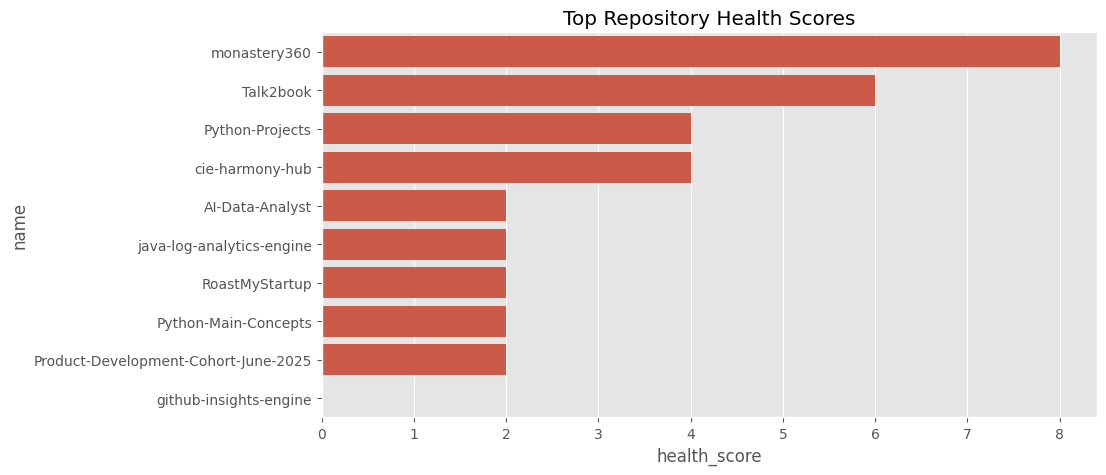

In [12]:
top_health = df.sort_values(
    by="health_score",
    ascending=False
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_health.head(10),
    x="health_score",
    y="name"
)

plt.title("Top Repository Health Scores")

plt.show()

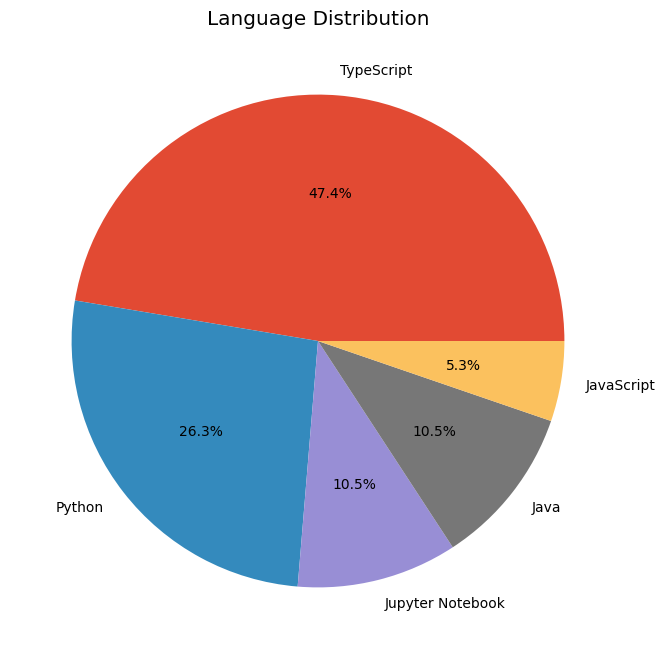

In [13]:
language_counts = df["language"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    language_counts,
    labels=language_counts.index,
    autopct="%1.1f%%"
)

plt.title("Language Distribution")

plt.show()

In [14]:
df.to_csv("../data/repository_data.csv", index=False)